In [209]:
import yfinance as yf

In [210]:
import numpy as np

In [211]:
import pandas as pd

In [212]:
import matplotlib.pyplot as plt

In [213]:
import sys, os

In [214]:
sys.path.append(os.path.abspath(".."))

In [215]:
import equitytools_local.data as datatools

In [216]:
from importlib import reload
reload(datatools)

<module 'equitytools_local.data' from 'C:\\Users\\jonsw\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\Scripts\\equitytools_local\\data.py'>

## User inputs are ticker, years, terminal_growth (terminal growth rate)

In [217]:
ticker = "AMZN"

In [218]:
years = 3

In [219]:
terminal_growth = 0.025

In [220]:
financial_data = datatools.get_company_financials(ticker)

# Let's assume the growth rate for the years up to the terminal year is the most current growth rate

In [221]:
current_growth_rate = (financial_data ["EBITDA"].iloc[0] / financial_data ["EBITDA"].iloc[1]) - 1

In [222]:
print(f"Current growth rate is estimated to be {current_growth_rate}")

Current growth rate is estimated to be 0.33538747324637574


In [223]:
print(  financial_data [["Date", "EBITDA"]] )

   Date          EBITDA
4  2025  165341000000.0
3  2024  123815000000.0
2  2023   89402000000.0
1  2022   38352000000.0


In [224]:
import equitytools_local.plotting as plottingtools

In [225]:
reload(plottingtools)

<module 'equitytools_local.plotting' from 'C:\\Users\\jonsw\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\Scripts\\equitytools_local\\plotting.py'>

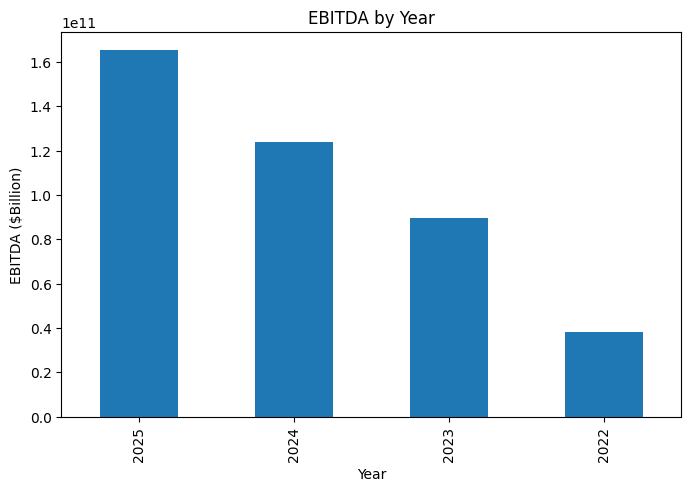

In [226]:
plottingtools.plot_ebitda_by_year(financial_data)

In [227]:
import equitytools_local.modeling as modelingtools

In [228]:
reload(modelingtools)

<module 'equitytools_local.modeling' from 'C:\\Users\\jonsw\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\Scripts\\equitytools_local\\modeling.py'>

In [229]:
financial_data = datatools.get_company_financials(ticker)

In [230]:
print(  financial_data [["Date", "EBITDA"]] )

   Date          EBITDA
4  2025  165341000000.0
3  2024  123815000000.0
2  2023   89402000000.0
1  2022   38352000000.0


In [231]:
fcf = financial_data ["EBITDA"].iloc[0]

In [232]:
print (fcf)

165341000000.0


In [233]:
stock = datatools.get_ticker_data(ticker)

In [234]:
print (stock)

yfinance.Ticker object <AMZN>


In [235]:
 shares = getattr(ticker, "fast_info", {}).get("shares_outstanding", None)


In [236]:
dict = stock.get_info()

In [237]:
shares =  (dict['sharesOutstanding'])

In [238]:
print (shares)

10734920870


In [239]:
beta = stock.info['beta']

In [240]:
growth_rate = current_growth_rate

In [241]:
current_price = stock.info['currentPrice']

In [242]:
total_equity = shares * current_price

In [243]:
total_debt = stock.balancesheet.loc["Total Debt"].iloc[0]

In [244]:
total_market_cap  = total_equity + total_debt

In [245]:
percent_equity = total_equity / total_market_cap

In [246]:
percent_debt = total_debt / total_market_cap

In [247]:
discount_rate = (abs(beta) * 0.10 * percent_equity) + (0.05 * percent_debt)

In [248]:
print (percent_equity)

0.9331052866316913


In [249]:
print (round(discount_rate, 4))

0.1326


In [250]:
print (beta)

1.385


In [251]:
intrinsic_value = round( modelingtools.dcf_valuation(fcf, shares, growth_rate, discount_rate, terminal_growth, years) , 2)

In [252]:
print (fcf)
print (shares)
print (fcf / shares)

165341000000.0
10734920870
15.402162903879887


In [253]:
print (intrinsic_value)

305.36


In [254]:
current_price = stock.info['currentPrice']

In [255]:
print (current_price)

198.79
